In [7]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Setup plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
# 2. Load Datasets
df_resume = pd.read_csv("../data/processed/resumes_cleaned.csv")
df_jd = pd.read_csv("../data/processed/jd_cleaned.csv")

print(f"Total Resumes: {len(df_resume)}")
print(f"Total Job Descriptions: {len(df_jd)}")
display(df_resume.head(3))

Total Resumes: 2484
Total Job Descriptions: 3909


,ID,label,text,cleaned_text
0,16852973,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,22323967,HR,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,33176873,HR,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...


## Analisis Kategori Pekerjaan pada Resume

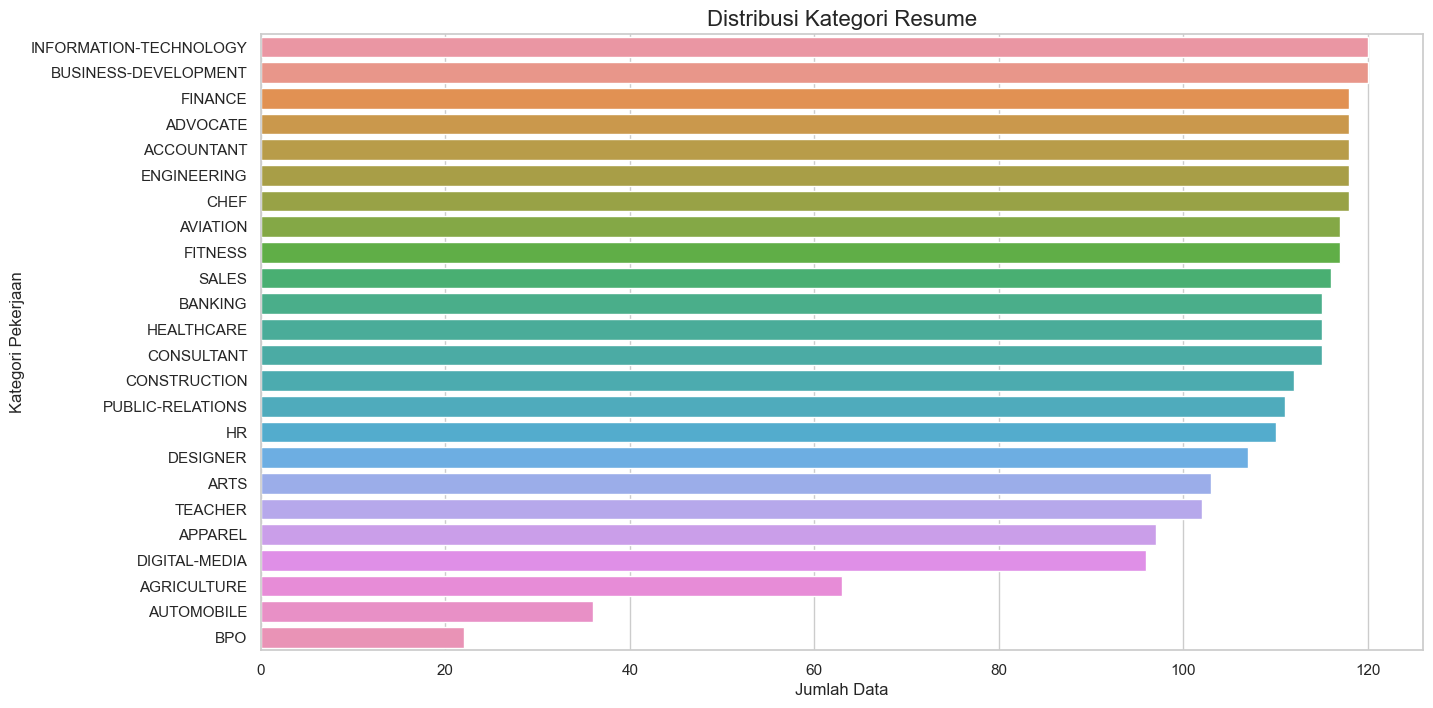

In [4]:
# 3. Distribusi Kategori (Melihat imbalance data)
plt.figure(figsize=(15, 8))
ax = sns.countplot(y="label", data=df_resume, order=df_resume["label"].value_counts().index)
plt.title("Distribusi Kategori Resume", fontsize=16)
plt.xlabel("Jumlah Data", fontsize=12)
plt.ylabel("Kategori Pekerjaan", fontsize=12)
plt.show()

## Analisis Panjang Teks (Word Count)

C:\Users\Willy Hanafi\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Willy Hanafi\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


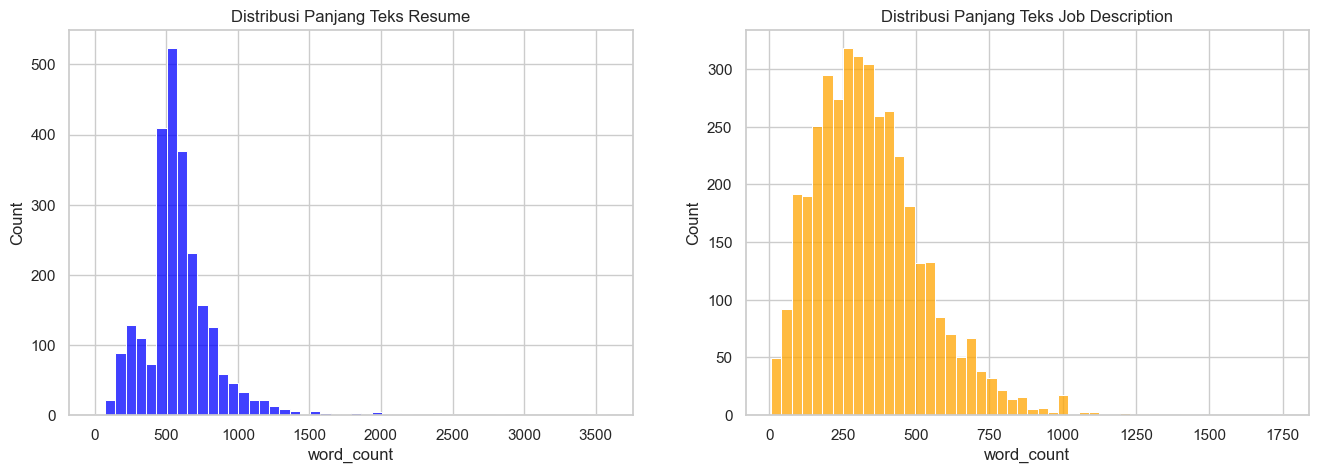

In [5]:
# 4. Menghitung jumlah kata per baris
df_resume["word_count"] = df_resume["cleaned_text"].apply(lambda x: len(str(x).split()))
df_jd["word_count"] = df_jd["cleaned_text"].apply(lambda x: len(str(x).split()))

# Plot distribusi panjang teks
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_resume["word_count"], bins=50, ax=axes[0], color="blue")
axes[0].set_title("Distribusi Panjang Teks Resume")

sns.histplot(df_jd["word_count"], bins=50, ax=axes[1], color="orange")
axes[1].set_title("Distribusi Panjang Teks Job Description")

plt.show()

## Kata Paling Sering Muncul (Term Frequency)

C:\Users\Willy Hanafi\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


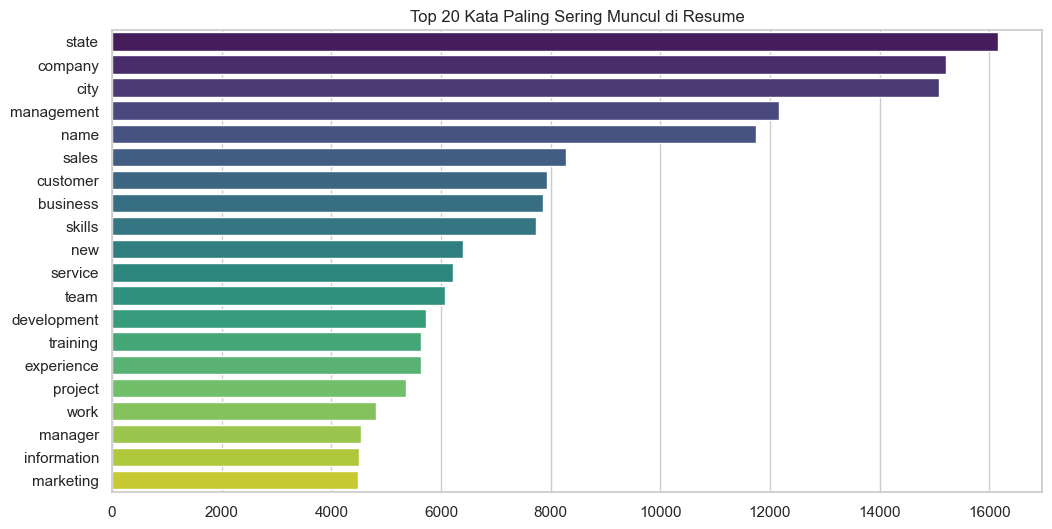

In [6]:
# 5. Top 20 kata terbanyak di seluruh Resume
all_resume_text = " ".join(df_resume["cleaned_text"].dropna())
resume_words = all_resume_text.split()
resume_word_counts = Counter(resume_words).most_common(20)

words, counts = zip(*resume_word_counts)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Kata Paling Sering Muncul di Resume")
plt.show()